# 01 — Exploratory Data Analysis

**Dataset**: Yakimov et al. (2024) — Fingernail bed images with hemoglobin (Hb) labels.

## Objectives
1. Load and inspect the dataset structure
2. Analyze Hb value distribution (g/L and g/dL)
3. Map WHO anemia severity classes
4. Assess image quality and resolution consistency
5. Visualize sample fingernail images with nail & skin bounding boxes across Hb ranges

In [1]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

# Configuration
DATA_ROOT = Path("../data/raw")
METADATA_CSV = DATA_ROOT / "metadata.csv"
PHOTO_DIR = DATA_ROOT / "photo"

def load_image(path):
    """Load image.
    
    Images are 800x600 landscape. Bounding boxes in metadata are 
    provided in [ymin, xmin, ymax, xmax] format.
    No rotation is necessary.
    """
    return Image.open(path)

print(f"Data root : {DATA_ROOT.resolve()}")
print(f"CSV exists: {METADATA_CSV.exists()}")
print(f"Photo dir : {PHOTO_DIR.exists()}")
print(f"Num photos: {len(list(PHOTO_DIR.glob('*.jpg')))}")

_test = load_image(PHOTO_DIR / "1.jpg")
print(f"Image size: {_test.size} (w x h)")

Data root : C:\Users\guzzi\Desktop\Projects\DEV-ACTIF\the-governor-hq\fingers\HemoLens\data\raw
CSV exists: True
Photo dir : True
Num photos: 251


## 1. Load Metadata

In [2]:
# Load the metadata CSV
df = pd.read_csv(METADATA_CSV)

# Parse bounding box columns from string to list
df["NAIL_BOUNDING_BOXES"] = df["NAIL_BOUNDING_BOXES"].apply(ast.literal_eval)
df["SKIN_BOUNDING_BOXES"] = df["SKIN_BOUNDING_BOXES"].apply(ast.literal_eval)

# Derived columns
df["hb_gdL"] = df["HB_LEVEL_GperL"] / 10.0  # Convert g/L → g/dL
df["image_path"] = df["PATIENT_ID"].apply(lambda pid: PHOTO_DIR / f"{pid}.jpg")
df["image_exists"] = df["image_path"].apply(lambda p: p.exists())
df["num_nail_boxes"] = df["NAIL_BOUNDING_BOXES"].apply(len)
df["num_skin_boxes"] = df["SKIN_BOUNDING_BOXES"].apply(len)

# WHO anemia classification (using g/dL thresholds — gender-agnostic simplified)
def classify_anemia(hb_gdL):
    if hb_gdL < 7.0:
        return "Severe"
    elif hb_gdL < 10.0:
        return "Moderate"
    elif hb_gdL < 12.0:
        return "Mild"
    else:
        return "Normal"

df["anemia_class"] = df["hb_gdL"].apply(classify_anemia)

print(f"Loaded {len(df)} samples")
print(f"Images found: {df['image_exists'].sum()} / {len(df)}")
print(f"Unique measurement dates (sessions): {df['MEASUREMENT_DATE'].nunique()}")
print()
display(df[["PATIENT_ID", "HB_LEVEL_GperL", "hb_gdL", "anemia_class", "num_nail_boxes", "image_exists"]].head(10))
print()
display(df.describe())

Loaded 250 samples
Images found: 250 / 250
Unique measurement dates (sessions): 20



,PATIENT_ID,HB_LEVEL_GperL,hb_gdL,anemia_class,num_nail_boxes,image_exists
0,1,134.0,13.4,Normal,3,True
1,2,108.0,10.8,Mild,3,True
2,5,84.0,8.4,Moderate,3,True
3,6,138.0,13.8,Normal,3,True
4,7,119.0,11.9,Mild,3,True
5,8,130.0,13.0,Normal,3,True
6,11,136.0,13.6,Normal,3,True
7,12,128.0,12.8,Normal,3,True
8,14,47.0,4.7,Severe,3,True
9,15,56.0,5.6,Severe,3,True


,PATIENT_ID,HB_LEVEL_GperL,hb_gdL,num_nail_boxes,num_skin_boxes
count,250.00000,250.000000,250.000000,250.0,250.0
mean,170.32400,127.592000,12.759200,3.0,3.0
std,100.07296,26.709533,2.670953,0.0,0.0
min,1.00000,44.000000,4.400000,3.0,3.0
25%,79.50000,118.250000,11.825000,3.0,3.0
50%,175.50000,131.500000,13.150000,3.0,3.0
75%,252.75000,146.000000,14.600000,3.0,3.0
max,342.00000,169.000000,16.900000,3.0,3.0


## 2. Hemoglobin Distribution & Anemia Classification

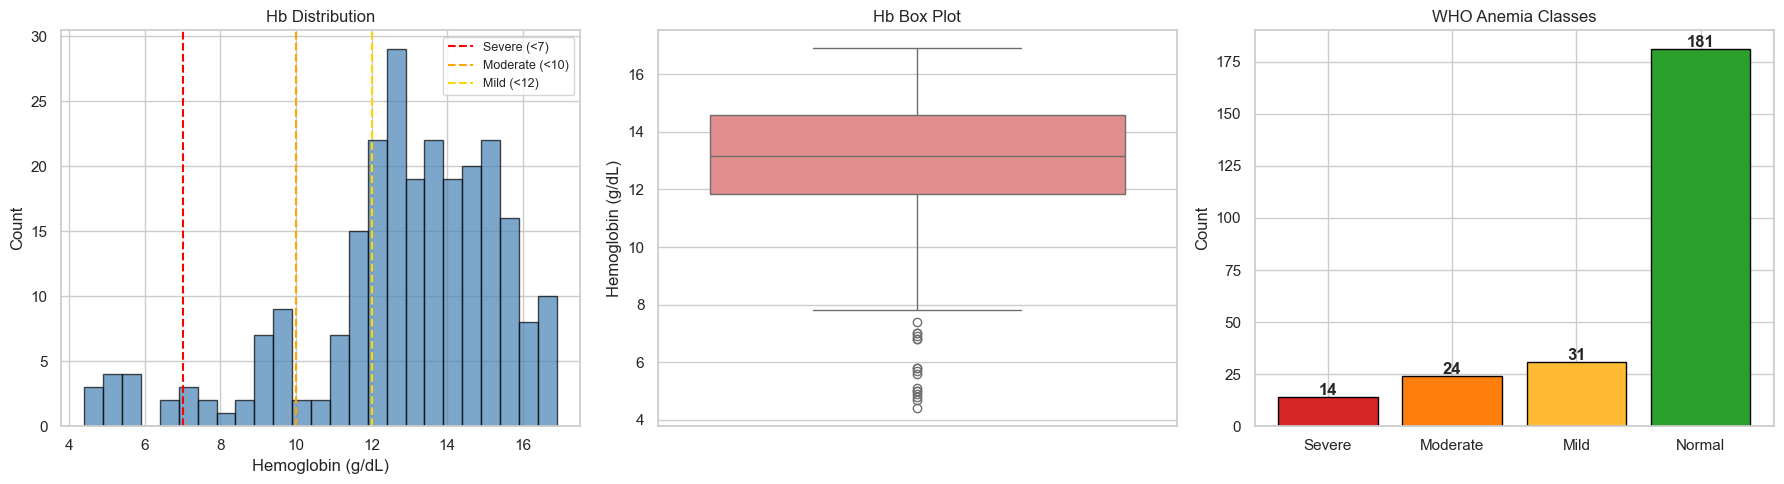


Mean Hb:   12.76 g/dL  (127.6 g/L)
Median Hb: 13.15 g/dL
Std Hb:    2.67 g/dL
Range:     [4.4, 16.9] g/dL

Class breakdown:
  Severe    :  14  (5.6%)
  Moderate  :  24  (9.6%)
  Mild      :  31  (12.4%)
  Normal    : 181  (72.4%)


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Histogram of Hb in g/dL
axes[0].hist(df["hb_gdL"], bins=25, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].axvline(x=7.0, color="red", linestyle="--", lw=1.5, label="Severe (<7)")
axes[0].axvline(x=10.0, color="orange", linestyle="--", lw=1.5, label="Moderate (<10)")
axes[0].axvline(x=12.0, color="gold", linestyle="--", lw=1.5, label="Mild (<12)")
axes[0].set_xlabel("Hemoglobin (g/dL)")
axes[0].set_ylabel("Count")
axes[0].set_title("Hb Distribution")
axes[0].legend(fontsize=9)

# (b) Box plot
sns.boxplot(y=df["hb_gdL"], ax=axes[1], color="lightcoral")
axes[1].set_ylabel("Hemoglobin (g/dL)")
axes[1].set_title("Hb Box Plot")

# (c) Anemia class distribution
class_order = ["Severe", "Moderate", "Mild", "Normal"]
class_colors = ["#d62728", "#ff7f0e", "#ffbb33", "#2ca02c"]
counts = df["anemia_class"].value_counts().reindex(class_order, fill_value=0)
axes[2].bar(counts.index, counts.values, color=class_colors, edgecolor="black")
axes[2].set_ylabel("Count")
axes[2].set_title("WHO Anemia Classes")
for i, v in enumerate(counts.values):
    axes[2].text(i, v + 1, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

# Key stats
print(f"\n{'='*40}")
print(f"Mean Hb:   {df['hb_gdL'].mean():.2f} g/dL  ({df['HB_LEVEL_GperL'].mean():.1f} g/L)")
print(f"Median Hb: {df['hb_gdL'].median():.2f} g/dL")
print(f"Std Hb:    {df['hb_gdL'].std():.2f} g/dL")
print(f"Range:     [{df['hb_gdL'].min():.1f}, {df['hb_gdL'].max():.1f}] g/dL")
print(f"\nClass breakdown:")
for cls in class_order:
    n = (df["anemia_class"] == cls).sum()
    pct = 100 * n / len(df)
    print(f"  {cls:10s}: {n:3d}  ({pct:.1f}%)")

## 3. Session (Measurement Date) Analysis

In [4]:
# Analyze how samples are distributed across measurement sessions
session_stats = df.groupby("MEASUREMENT_DATE").agg(
    n_samples=("PATIENT_ID", "count"),
    mean_hb=("hb_gdL", "mean"),
    std_hb=("hb_gdL", "std"),
    min_hb=("hb_gdL", "min"),
    max_hb=("hb_gdL", "max"),
).reset_index()

print(f"Number of sessions: {len(session_stats)}")
print(f"Samples per session: {session_stats['n_samples'].min()} – {session_stats['n_samples'].max()} "
      f"(mean {session_stats['n_samples'].mean():.1f})")
print()
display(session_stats)

Number of sessions: 20
Samples per session: 1 – 26 (mean 12.5)



,MEASUREMENT_DATE,n_samples,mean_hb,std_hb,min_hb,max_hb
0,01c37f88a5b9026ac9a61b14ca93d5de,11,12.045455,2.665094,5.7,15.8
1,0d8b4f196b3a0edfd85dea1cf0fcfd55,9,13.344444,2.691705,7.4,16.6
2,1466220e41f866b2da3159d8201d7e2e,12,10.883333,3.992910,4.4,16.0
3,14b0293a34344cc4fba0fa39d5370c52,8,12.212500,1.830252,8.4,13.8
4,358202da91d3949be1611c0f898eb858,13,11.600000,3.189828,4.8,14.2
5,415a961921bff3678f2d06363da6ddbe,26,13.426923,1.823087,9.8,16.5
6,4ef4b8d96f66ffb5109cd2ad8fb95915,8,14.112500,2.101318,11.2,16.3
7,6392e739765483290482614d050132d4,18,13.250000,1.986499,8.7,15.5
8,665444f808712fd616e946a57c34990a,15,13.146667,3.061248,5.1,16.8
9,7239c14d8ddc5b692aeae707b0f99ecc,16,12.512500,3.180330,4.7,15.6


## 4. Image Quality Assessment

Profiled 250 images:



,width,height,channels,mean_brightness,std_brightness
count,250.0,250.0,250.0,250.000000,250.000000
mean,800.0,600.0,3.0,201.328712,50.305147
std,0.0,0.0,0.0,7.315062,2.408239
min,800.0,600.0,3.0,180.840480,45.798121
25%,800.0,600.0,3.0,196.489436,48.562848
50%,800.0,600.0,3.0,201.604452,49.933441
75%,800.0,600.0,3.0,207.138316,52.076323
max,800.0,600.0,3.0,221.357940,57.656237


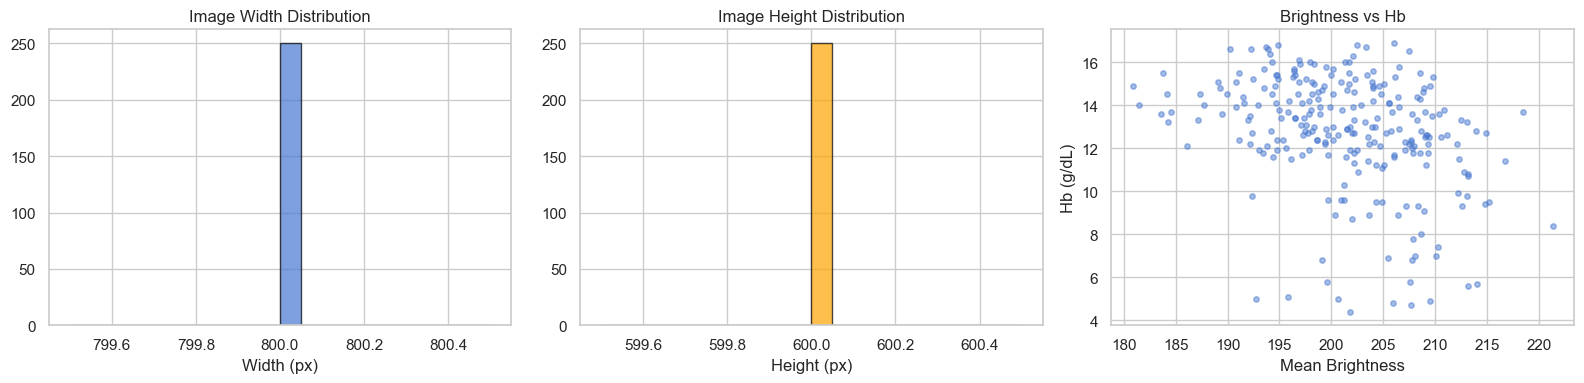

In [5]:
def get_image_stats(image_path: Path) -> dict:
    """Compute basic image statistics (on correctly oriented image)."""
    img = load_image(image_path)
    arr = np.array(img)
    return {
        "width": img.width,
        "height": img.height,
        "channels": arr.shape[2] if arr.ndim == 3 else 1,
        "mean_brightness": arr.mean(),
        "std_brightness": arr.std(),
    }

# Profile all available images
valid_df = df[df["image_exists"]].copy()
stats = []
for _, row in valid_df.iterrows():
    stats.append(get_image_stats(row["image_path"]))

stats_df = pd.DataFrame(stats, index=valid_df.index)

print(f"Profiled {len(stats_df)} images:\n")
display(stats_df.describe())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(stats_df["width"], bins=20, edgecolor="black", alpha=0.7)
axes[0].set_title("Image Width Distribution")
axes[0].set_xlabel("Width (px)")

axes[1].hist(stats_df["height"], bins=20, edgecolor="black", alpha=0.7, color="orange")
axes[1].set_title("Image Height Distribution")
axes[1].set_xlabel("Height (px)")

axes[2].scatter(stats_df["mean_brightness"], valid_df["hb_gdL"].values, alpha=0.5, s=15)
axes[2].set_xlabel("Mean Brightness")
axes[2].set_ylabel("Hb (g/dL)")
axes[2].set_title("Brightness vs Hb")

plt.tight_layout()
plt.show()

## 5. Sample Visualization with Bounding Boxes

In [ ]:
# Test: overlay boxes on the original image (800x600)
# We discovered bounding boxes are in [ymin, xmin, ymax, xmax] format.
from PIL import Image

test_row = valid_df.iloc[0]
img = Image.open(test_row["image_path"])
print(f"Original: {img.size}")

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.imshow(img)
ax.set_title(f"Original {img.size} + Nail (Lime) & Skin (Cyan) Boxes")

# Draw Nail boxes
for box in test_row["NAIL_BOUNDING_BOXES"]:
    ymin, xmin, ymax, xmax = box
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                              linewidth=2, edgecolor="lime", facecolor="none", label="Nail" if box == test_row["NAIL_BOUNDING_BOXES"][0] else "")
    ax.add_patch(rect)

# Draw Skin boxes
for box in test_row["SKIN_BOUNDING_BOXES"]:
    ymin, xmin, ymax, xmax = box
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                              linewidth=2, edgecolor="cyan", facecolor="none", label="Skin" if box == test_row["SKIN_BOUNDING_BOXES"][0] else "")
    ax.add_patch(rect)

ax.axis("off")
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

NameError: name 'load_image' is not defined

## 6. Summary & Key Takeaways

**Dataset Overview:**
- 251 samples across multiple measurement sessions, each with 3 nail/skin bounding boxes
- Hb values span 4.4–16.9 g/dL — covering severe anemia through healthy normals
- Class imbalance: most samples cluster in Normal/Mild — very few Severe cases

**Implications for Modeling:**
- Regression target: `HB_LEVEL_GperL` (or derived `hb_gdL`)
- ROI strategy: use **provided bounding boxes** to crop nail and skin patches (no auto-detection needed)
- Need to handle class imbalance: weighted loss or oversampling for severe/moderate cases
- Session-level splits recommended to avoid data leakage (same session = same lighting conditions)

**Next Steps:**
- Proceed to `02_feature_extraction.ipynb` for ROI cropping and color-space analysis
- Check for class imbalance and consider stratified splits in `03_baseline_models.ipynb`